In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

In [2]:
url_str = "https://en.wikipedia.org/wiki/Quokka"

In [3]:
headers = {"User-Agent":"Mozilla/5.0 (student-lab)"}

In [4]:
r = requests.get(url_str, headers=headers, timeout=30)

In [5]:
r

<Response [200]>

In [6]:
r.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Quokka - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-featur

In [7]:
soup = BeautifulSoup(r.text, "lxml")



In [8]:
h1_elements = soup.find_all("h1")

In [10]:
h1_elements

[<h1 class="firstHeading mw-first-heading" id="firstHeading"><span class="mw-page-title-main">Quokka</span></h1>]

In [9]:
h1_raw = [h.get_text() for h in h1_elements]
h1_raw

['Quokka']

In [10]:
pd.DataFrame(h1_raw)

,0
0,Quokka


In [15]:
h2_elements = soup.find_all("h2")
h2_raw = [h.get_text() for h in h2_elements]
pd.DataFrame(h2_raw)

,0
0,Contents
1,Description
2,Discovery and name
3,Ecology
4,Diet
5,Population
6,Conservation
7,Human interaction
8,Quokka selfies
9,See also


In [16]:
a_elems = soup.find_all("a")
a_elems

[<a class="mw-jump-link" href="#bodyContent">Jump to content</a>,
 <a accesskey="z" href="/wiki/Main_Page" title="Visit the main page [z]"><span>Main page</span></a>,
 <a href="/wiki/Wikipedia:Contents" title="Guides to browsing Wikipedia"><span>Contents</span></a>,
 <a href="/wiki/Portal:Current_events" title="Articles related to current events"><span>Current events</span></a>,
 <a accesskey="x" href="/wiki/Special:Random" title="Visit a randomly selected article [x]"><span>Random article</span></a>,
 <a href="/wiki/Wikipedia:About" title="Learn about Wikipedia and how it works"><span>About Wikipedia</span></a>,
 <a href="//en.wikipedia.org/wiki/Wikipedia:Contact_us" title="How to contact Wikipedia"><span>Contact us</span></a>,
 <a href="/wiki/Help:Contents" title="Guidance on how to use and edit Wikipedia"><span>Help</span></a>,
 <a href="/wiki/Help:Introduction" title="Learn how to edit Wikipedia"><span>Learn to edit</span></a>,
 <a href="/wiki/Wikipedia:Community_portal" title="The

In [24]:
my_links=[]
for a in a_elems:
  href = a.get("href")

  try:
    if "https" in href:
      print(href)
      my_links.append(href)
  except:
    pass

https://donate.wikimedia.org/?wmf_source=donate&wmf_medium=sidebar&wmf_campaign=en.wikipedia.org&uselang=en
https://donate.wikimedia.org/?wmf_source=donate&wmf_medium=sidebar&wmf_campaign=en.wikipedia.org&uselang=en
https://ar.wikipedia.org/wiki/%D9%83%D9%88%D9%83%D8%A7_(%D8%AD%D9%8A%D9%88%D8%A7%D9%86)
https://gn.wikipedia.org/wiki/K%C3%BAoka
https://az.wikipedia.org/wiki/Kvokka
https://azb.wikipedia.org/wiki/%D8%B3%D8%AA%D9%88%D9%86%DB%8C%DA%A9%D8%B3_%D8%A8%D8%B1%D8%A7%DA%86%DB%8C%D9%88%D8%B1%D9%88%D8%B3
https://zh-min-nan.wikipedia.org/wiki/Quokka
https://be.wikipedia.org/wiki/%D0%9A%D0%B2%D0%BE%D0%BA%D0%B0
https://bg.wikipedia.org/wiki/%D0%9A%D1%83%D0%BE%D0%BA%D0%B0
https://br.wikipedia.org/wiki/Kwoka
https://ca.wikipedia.org/wiki/Quoca
https://ceb.wikipedia.org/wiki/Setonix_brachyurus
https://cs.wikipedia.org/wiki/Klokan_quokka
https://cy.wikipedia.org/wiki/Cwoca
https://da.wikipedia.org/wiki/Quokka
https://de.wikipedia.org/wiki/Quokka
https://nv.wikipedia.org/wiki/Nahat%CA%BCe%CA%

In [27]:
pd.DataFrame(my_links, columns=["Links"])

,Links
0,https://donate.wikimedia.org/?wmf_source=donat...
1,https://donate.wikimedia.org/?wmf_source=donat...
2,https://ar.wikipedia.org/wiki/%D9%83%D9%88%D9%...
3,https://gn.wikipedia.org/wiki/K%C3%BAoka
4,https://az.wikipedia.org/wiki/Kvokka
...,...
178,https://developer.wikimedia.org
179,https://stats.wikimedia.org/#/en.wikipedia.org
180,https://foundation.wikimedia.org/wiki/Special:...
181,https://www.wikimedia.org/


In [28]:
img_elems = soup.find_all("img")

In [33]:
my_imgs = []
for img in img_elems:
  src = img.get("src")
  file_extension = src[-3:]

  if file_extension != "svg":
      print(src)

  if src[0:2] == "//":
      print(src[2:])
      my_imgs.append(src[2:])

/static/images/icons/wikipedia.png
//upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/20px-Semi-protection-shackle.svg.png
upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/20px-Semi-protection-shackle.svg.png
//upload.wikimedia.org/wikipedia/commons/thumb/5/54/Quokka_at_rottnest_%28cropped%29.jpg/250px-Quokka_at_rottnest_%28cropped%29.jpg
upload.wikimedia.org/wikipedia/commons/thumb/5/54/Quokka_at_rottnest_%28cropped%29.jpg/250px-Quokka_at_rottnest_%28cropped%29.jpg
//upload.wikimedia.org/wikipedia/commons/thumb/6/63/Status_iucn3.1_VU.svg/250px-Status_iucn3.1_VU.svg.png
upload.wikimedia.org/wikipedia/commons/thumb/6/63/Status_iucn3.1_VU.svg/250px-Status_iucn3.1_VU.svg.png
//upload.wikimedia.org/wikipedia/commons/thumb/8/8a/OOjs_UI_icon_edit-ltr.svg/20px-OOjs_UI_icon_edit-ltr.svg.png
upload.wikimedia.org/wikipedia/commons/thumb/8/8a/OOjs_UI_icon_edit-ltr.svg/20px-OOjs_UI_icon_edit-ltr.svg.png
//upload.wikimedia.org/wikipedia/commons/thumb/

In [34]:
my_imgs

['upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/20px-Semi-protection-shackle.svg.png',
 'upload.wikimedia.org/wikipedia/commons/thumb/5/54/Quokka_at_rottnest_%28cropped%29.jpg/250px-Quokka_at_rottnest_%28cropped%29.jpg',
 'upload.wikimedia.org/wikipedia/commons/thumb/6/63/Status_iucn3.1_VU.svg/250px-Status_iucn3.1_VU.svg.png',
 'upload.wikimedia.org/wikipedia/commons/thumb/8/8a/OOjs_UI_icon_edit-ltr.svg/20px-OOjs_UI_icon_edit-ltr.svg.png',
 'upload.wikimedia.org/wikipedia/commons/thumb/2/22/Setonix_brachyurus_distribution.svg/250px-Setonix_brachyurus_distribution.svg.png',
 'upload.wikimedia.org/wikipedia/commons/thumb/8/8d/Quokka_family.jpg/250px-Quokka_family.jpg',
 'upload.wikimedia.org/wikipedia/commons/thumb/9/98/Quokka_Selfie.jpg/250px-Quokka_Selfie.jpg',
 'upload.wikimedia.org/wikipedia/commons/thumb/e/e7/RottnestQuokka.jpg/250px-RottnestQuokka.jpg',
 'upload.wikimedia.org/wikipedia/en/thumb/4/4a/Commons-logo.svg/40px-Commons-logo.svg.png',
 'upload.wi

In [35]:
urls = ["https://" + u for u in my_imgs]

In [36]:
urls

['https://upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/20px-Semi-protection-shackle.svg.png',
 'https://upload.wikimedia.org/wikipedia/commons/thumb/5/54/Quokka_at_rottnest_%28cropped%29.jpg/250px-Quokka_at_rottnest_%28cropped%29.jpg',
 'https://upload.wikimedia.org/wikipedia/commons/thumb/6/63/Status_iucn3.1_VU.svg/250px-Status_iucn3.1_VU.svg.png',
 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/OOjs_UI_icon_edit-ltr.svg/20px-OOjs_UI_icon_edit-ltr.svg.png',
 'https://upload.wikimedia.org/wikipedia/commons/thumb/2/22/Setonix_brachyurus_distribution.svg/250px-Setonix_brachyurus_distribution.svg.png',
 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/Quokka_family.jpg/250px-Quokka_family.jpg',
 'https://upload.wikimedia.org/wikipedia/commons/thumb/9/98/Quokka_Selfie.jpg/250px-Quokka_Selfie.jpg',
 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/e7/RottnestQuokka.jpg/250px-RottnestQuokka.jpg',
 'https://upload.wikimedia.org/wikipedi

In [38]:
from PIL import Image
from io import BytesIO

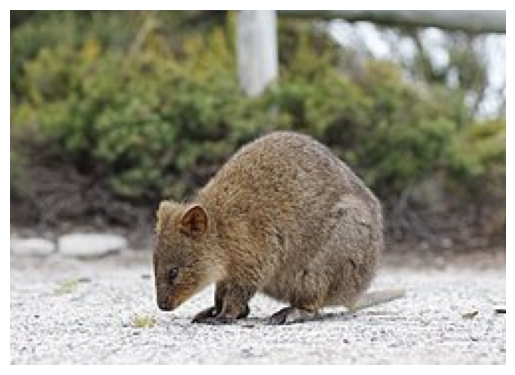

In [39]:
image_url = urls[1]

r = requests.get(image_url, headers={"User-Agent":"Mozilla/5.0 (DS-3001)"}, timeout=20)
r.raise_for_status()

ct = r.headers.get("Content-Type","")
if "image/svg+xml" in ct or image_url.lower().endswith(".svg"):
    raise ValueError("This URL is an SVG; PIL can't open it directly.")

if "image" not in ct:
    raise ValueError(f"Not an image. Content-Type={ct}")

im = Image.open(BytesIO(r.content)).convert("RGBA")  # use content, not raw
plt.imshow(im); plt.axis("off"); plt.show()